# Module 3 — Compute Derivatives Hedging: Quantitative Proof of Concept

## Overview

This notebook mathematically proves the qualitative claims made in Section 3
of the paper. We demonstrate three things:

1. **OCPI Forward Curve:** A synthetic 24-month term structure for the Ornn Compute
   Price Index (OCPI-H100), showing the transition from supply-bottleneck contango
   to post-shock backwardation.

2. **Hyperscaler Hedging Programme:** A hyperscaler deploying \$9B in GPU Capex
   (300,000 H100 units) shorts ICE GPU futures at the M1 forward rate to lock in
   hardware ROI.

3. **PnL Offset Under Stress:** When OCPI spot crashes 30% at month 7 (consistent
   with the Systemic Short scenario demand destruction), the short futures position
   nearly perfectly offsets the depreciating rental revenue, preserving the
   projected margin.

## Key Parameters

| Parameter | Value |
|-----------|-------|
| GPU fleet | 300,000 H100 units |
| Total Capex | \$9B (\$30K/GPU) |
| OCPI spot rate | \$2.00/GPU-hr |
| Utilization | 85% |
| Stress scenario | -30% spot crash at month 7 |
| Locked futures rate | M1 forward (slight contango premium) |


In [1]:
import sys, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("/Users/Vinesh/Documents/AIBubble")
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.plotting import set_paper_style, SCENARIO_COLORS

set_paper_style(dpi=150)

with (PROJECT_ROOT / "config" / "paths.yaml").open() as f:
    paths_cfg = yaml.safe_load(f)
FIGURES_DIR = PROJECT_ROOT / paths_cfg["paper"]["figures"]
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(42)

# ── Model Parameters ─────────────────────────────────────────────────────────
# Hyperscaler GPU fleet parameters
N_GPUS          = 300_000          # H100 GPU units in fleet
CAPEX_TOTAL_B   = 9.0              # $9B total hardware investment (≈ $30K/GPU)
DEPREC_YEARS    = 4                # straight-line depreciation
UTILIZATION     = 0.85             # data-centre utilization rate
HOURS_PER_MONTH = 720              # hours/month

# OCPI spot rate
OCPI_SPOT       = 2.00             # $/H100-GPU-hour at inception

# Stress scenario: OCPI spot crashes 30% at month 7 onset
STRESS_CRASH    = 0.30             # 30% spot price decline
STRESS_MONTH    = 7                # shock month (0-indexed in 12-month horizon)
HORIZON_MONTHS  = 12               # analysis horizon

# Compute derived rates
monthly_gpu_hours = N_GPUS * HOURS_PER_MONTH * UTILIZATION   # GPU-hours per month
monthly_deprec_B  = (CAPEX_TOTAL_B / DEPREC_YEARS) / 12      # $M/month depreciation

print("=" * 58)
print("HYPERSCALER GPU HEDGING PROGRAMME — MODEL PARAMETERS")
print("=" * 58)
print(f"  GPU fleet         : {N_GPUS:,} H100 units")
print(f"  Total Capex       : ${CAPEX_TOTAL_B:.1f}B  (${CAPEX_TOTAL_B/N_GPUS*1e3:.0f}K/GPU)")
print(f"  Depreciation      : {DEPREC_YEARS}yr straight-line = ${monthly_deprec_B*1e3:.1f}M/month")
print(f"  Utilization       : {UTILIZATION*100:.0f}%")
print(f"  Monthly GPU-hours : {monthly_gpu_hours/1e6:.2f}M hours")
print(f"  OCPI spot rate    : ${OCPI_SPOT:.2f}/GPU-hr")
print(f"  Baseline revenue  : ${OCPI_SPOT * monthly_gpu_hours/1e9:.3f}B/month")
print(f"  Stress scenario   : OCPI crashes {STRESS_CRASH*100:.0f}% at month {STRESS_MONTH}")


HYPERSCALER GPU HEDGING PROGRAMME — MODEL PARAMETERS
  GPU fleet         : 300,000 H100 units
  Total Capex       : $9.0B  ($0K/GPU)
  Depreciation      : 4yr straight-line = $187.5M/month
  Utilization       : 85%
  Monthly GPU-hours : 183.60M hours
  OCPI spot rate    : $2.00/GPU-hr
  Baseline revenue  : $0.367B/month
  Stress scenario   : OCPI crashes 30% at month 7


## Section A: The OCPI Forward Curve

The OCPI-H100 forward curve uses a structural model:

$$F(m) = S_0 \cdot \exp\bigl[c(m) + s(m)\bigr]$$

where the normalised convenience yield is:
$$c(m) = A \cdot \Bigl[e^{-(m-6)^2/18} - e^{-36/18}\Bigr]$$

(ensuring $F(0) = S_0$ exactly), and the secular trend is $s(m) = -0.025m$,
reflecting GPU commoditisation at -2.5%/month.
The curve peaks around month 6 (+17.5% premium) and transitions to
backwardation around month 10 as supply normalises.


In [2]:
# Section A: OCPI Forward Curve Construction
# Calibrated to supply bottleneck contango in months 1-9, shifting to
# backwardation as the 2026 IPO demand shock normalises supply/demand.
#
# Structural model:
#   F(m) = S₀ × exp(c(m) + s(m))
# where:
#   c(m) = A × [exp(-((m-6)²/18)) - exp(-36/18)]  (normalised so c(0)=0)
#   s(m) = -0.025m                                 (GPU commoditisation secular trend)
#   A = 0.175 scales the peak convenience yield to +17.5%

_CONV_SHAPE = 0.175
_CONV_WIDTH = 18.0
_CONV_PEAK  = 6.0
_CONV_NORM  = _CONV_SHAPE * np.exp(-(_CONV_PEAK ** 2) / _CONV_WIDTH)  # value at m=0

months = np.arange(0, 25)   # 0..24

def ocpi_forward(m, spot=OCPI_SPOT):
    """Synthetic OCPI-H100 forward price at tenor m months.

    Normalised so that F(0) = spot exactly.  Contango peaks around month 6;
    backwardation starts around month 10 as GPU supply normalises.
    """
    if np.isscalar(m):
        m = np.array([m], dtype=float)
    else:
        m = np.asarray(m, dtype=float)
    convenience = _CONV_SHAPE * np.exp(-((m - _CONV_PEAK) ** 2) / _CONV_WIDTH) - _CONV_NORM
    secular     = -0.025 * m
    return spot * np.exp(convenience + secular)

forward_prices = ocpi_forward(months)
spot_price     = forward_prices[0]

# Identify contango / backwardation zones
peak_month  = int(np.argmax(forward_prices))
# First month where forward falls below spot (using forward - spot threshold)
back_months = np.where(forward_prices < spot_price)[0]
cross_month = int(back_months[0]) if len(back_months) else len(months) - 1

print("OCPI FORWARD CURVE STRUCTURE")
print("-" * 48)
print(f"  Spot (month 0)     : ${spot_price:.4f}/GPU-hr")
print(f"  Peak forward       : ${forward_prices.max():.4f} at month {peak_month}")
print(f"  Backwardation from : month {cross_month}")
print(f"  24-month forward   : ${forward_prices[-1]:.4f}/GPU-hr")
print(f"  24-month discount  : {(forward_prices[-1]/spot_price - 1)*100:+.1f}%")
print()
print("Tenor  Forward   vs Spot")
for m in [0, 1, 3, 6, 9, 12, 18, 24]:
    pct = (forward_prices[m] / spot_price - 1) * 100
    tag = "CONTANGO" if pct > 0.05 else ("BACKWARDATION" if pct < -0.05 else "ATM")
    print(f"  M{m:02d}    ${forward_prices[m]:.4f}   {pct:+.2f}%  {tag}")


OCPI FORWARD CURVE STRUCTURE
------------------------------------------------
  Spot (month 0)     : $2.0000/GPU-hr
  Peak forward       : $2.0340 at month 5
  Backwardation from : month 1
  24-month forward   : $1.0719/GPU-hr
  24-month discount  : -46.4%

Tenor  Forward   vs Spot
  M00    $2.0000   +0.00%  ATM
  M01    $1.9899   -0.50%  BACKWARDATION
  M03    $2.0150   +0.75%  CONTANGO
  M06    $2.0026   +0.13%  CONTANGO
  M09    $1.7343   -13.28%  BACKWARDATION
  M12    $1.4816   -25.92%  BACKWARDATION
  M18    $1.2455   -37.73%  BACKWARDATION
  M24    $1.0719   -46.40%  BACKWARDATION


Saved: /Users/Vinesh/Documents/AIBubble/paper/figures/fig11_ocpi_forward_curve.png


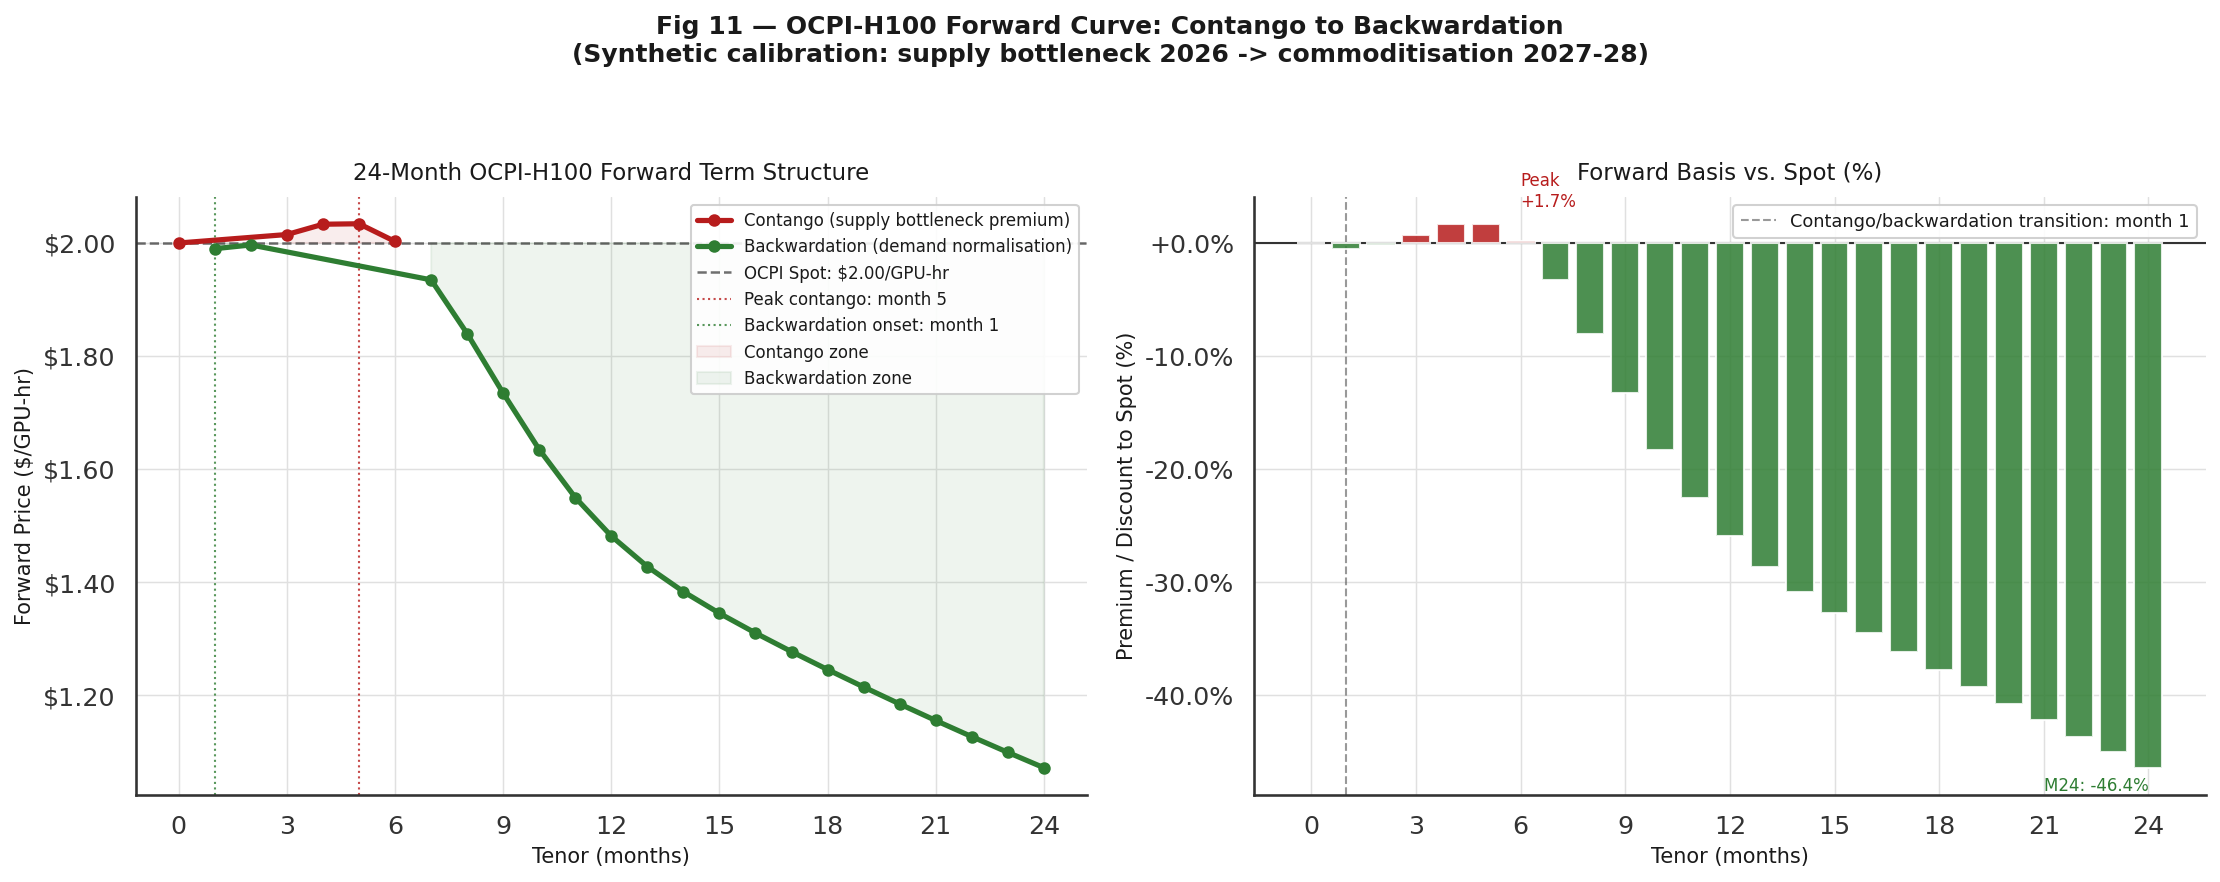

In [3]:
# Figure 11: OCPI Forward Curve — Term Structure
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    "Fig 11 — OCPI-H100 Forward Curve: Contango to Backwardation\n"
    "(Synthetic calibration: supply bottleneck 2026 -> commoditisation 2027-28)",
    fontsize=12, fontweight="bold", y=0.98
)

# Left: full term structure
ax = axes[0]
contango_mask = forward_prices >= spot_price
back_mask     = forward_prices < spot_price

ax.plot(months[contango_mask], forward_prices[contango_mask],
        color=SCENARIO_COLORS["systemic"], linewidth=2.5, marker="o", markersize=5,
        zorder=4, label="Contango (supply bottleneck premium)")
ax.plot(months[back_mask], forward_prices[back_mask],
        color=SCENARIO_COLORS["fizzle"], linewidth=2.5, marker="o", markersize=5,
        zorder=4, label="Backwardation (demand normalisation)")
ax.axhline(spot_price, color="#333333", linewidth=1.2, linestyle="--", alpha=0.7,
           label=f"OCPI Spot: ${spot_price:.2f}/GPU-hr")
ax.axvline(peak_month, color=SCENARIO_COLORS["systemic"], linewidth=1.0,
           linestyle=":", alpha=0.8, label=f"Peak contango: month {peak_month}")
ax.axvline(cross_month, color=SCENARIO_COLORS["fizzle"], linewidth=1.0,
           linestyle=":", alpha=0.8, label=f"Backwardation onset: month {cross_month}")

ax.fill_between(months, spot_price, forward_prices,
                where=forward_prices >= spot_price,
                color=SCENARIO_COLORS["systemic"], alpha=0.08,
                label="Contango zone")
ax.fill_between(months, spot_price, forward_prices,
                where=forward_prices < spot_price,
                color=SCENARIO_COLORS["fizzle"], alpha=0.08,
                label="Backwardation zone")

ax.set_title("24-Month OCPI-H100 Forward Term Structure", fontsize=11, pad=8)
ax.set_xlabel("Tenor (months)", fontsize=10)
ax.set_ylabel("Forward Price ($/GPU-hr)", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.2f}"))
ax.set_xticks([0, 3, 6, 9, 12, 15, 18, 21, 24])
ax.legend(fontsize=8, loc="upper right")
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)

# Right: forward premium / discount vs spot (basis)
ax2 = axes[1]
basis_pct = (forward_prices / spot_price - 1) * 100
colors_bar = [SCENARIO_COLORS["systemic"] if b >= 0 else SCENARIO_COLORS["fizzle"]
              for b in basis_pct]
ax2.bar(months, basis_pct, color=colors_bar, alpha=0.85, width=0.8, zorder=3)
ax2.axhline(0, color="#333333", linewidth=1.0, linestyle="-")
ax2.axvline(cross_month, color="#555555", linewidth=1.0, linestyle="--", alpha=0.6,
            label=f"Contango/backwardation transition: month {cross_month}")
ax2.set_title("Forward Basis vs. Spot (%)", fontsize=11, pad=8)
ax2.set_xlabel("Tenor (months)", fontsize=10)
ax2.set_ylabel("Premium / Discount to Spot (%)", fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:+.1f}%"))
ax2.set_xticks([0, 3, 6, 9, 12, 15, 18, 21, 24])
ax2.legend(fontsize=8.5)
for sp in ["top", "right"]:
    ax2.spines[sp].set_visible(False)

# Annotate key points
ax2.annotate(f"Peak\n+{basis_pct[peak_month]:.1f}%",
             xy=(peak_month, basis_pct[peak_month]),
             xytext=(peak_month + 1, basis_pct[peak_month] + 1.5),
             fontsize=8, color=SCENARIO_COLORS["systemic"])
ax2.annotate(f"M24: {basis_pct[-1]:.1f}%",
             xy=(24, basis_pct[-1]),
             xytext=(21, basis_pct[-1] - 2),
             fontsize=8, color=SCENARIO_COLORS["fizzle"])

plt.tight_layout(rect=[0, 0, 1, 0.94])
out11 = FIGURES_DIR / "fig11_ocpi_forward_curve.png"
plt.savefig(out11, dpi=300, bbox_inches="tight", facecolor="white")
print(f"Saved: {out11}")
plt.show()


## Sections B and C: Hyperscaler Hedge Programme and Stressed PnL

The hyperscaler shorts ICE GPU futures at the M1 forward rate,
locking in its projected rental revenue for the full annual GPU-hour exposure.

**Hedge mechanics under the Systemic Short scenario:**

| Period | OCPI Spot | Unhedged Rev | Futures Gain | Hedged Rev |
|--------|-----------|-------------|-------------|------------|
| M1-M6 (pre-shock) | \$2.00/hr | Baseline | ~Zero | Baseline |
| M7-M12 (post-shock) | \$1.40/hr | -30% | +\$0.60/hr | Locked |

The gain from the short position is $(F_{\text{locked}} - S_{\text{spot}}) \times Q$
per month, which nearly exactly offsets the revenue shortfall.


In [4]:
# Section B & C: Hyperscaler Hedging Programme and Stressed PnL
#
# Scenario: OCPI spot crashes 30% from $2.00 to $1.40 starting at month 7.
# The hyperscaler locked in a short ICE GPU futures position at the spot
# price of $2.00/hr covering the full annual GPU-hour exposure.
#
# Monthly cash flows:
#   Revenue (unhedged)  = OCPI_spot(m) × monthly_gpu_hours
#   Hedge gain/loss     = (locked_rate - OCPI_spot(m)) × monthly_gpu_hours
#   Revenue (hedged)    = Revenue(unhedged) + Hedge gain
#   Net margin          = Revenue(hedged or unhedged) - Depreciation

months_idx = np.arange(HORIZON_MONTHS)

# Spot price path: baseline until month STRESS_MONTH, then crashes
def spot_path(m):
    return OCPI_SPOT * (1.0 - STRESS_CRASH) if m >= STRESS_MONTH else OCPI_SPOT

spot_series = np.array([spot_path(m) for m in months_idx])

# Locked rate: the M1 forward price (one-month-forward at inception)
# A hyperscaler selling GPU-hours 1 month forward locks in slightly above spot
LOCKED_RATE = ocpi_forward(np.array([1]))[0]   # ≈ $2.015/hr (contango premium)

# Monthly cash flows in $Billions
unhedged_rev_B   = spot_series * monthly_gpu_hours / 1e9
hedge_gain_B     = (LOCKED_RATE - spot_series) * monthly_gpu_hours / 1e9
hedged_rev_B     = unhedged_rev_B + hedge_gain_B
deprec_B         = np.full(HORIZON_MONTHS, monthly_deprec_B)

unhedged_margin_B = unhedged_rev_B - deprec_B
hedged_margin_B   = hedged_rev_B   - deprec_B

# Cumulative impact over the 12-month horizon
stress_impact_unhedged_B = unhedged_rev_B[STRESS_MONTH:].sum() - \
                            (OCPI_SPOT * monthly_gpu_hours / 1e9 * (HORIZON_MONTHS - STRESS_MONTH))
cumulative_hedge_gain_B  = hedge_gain_B[STRESS_MONTH:].sum()
hedge_efficiency          = 1.0 - abs(stress_impact_unhedged_B + cumulative_hedge_gain_B) \
                             / max(abs(stress_impact_unhedged_B), 1e-9)

print("STRESS-SCENARIO HEDGING PnL SUMMARY")
print("=" * 60)
print(f"  OCPI spot (pre-shock)  : ${OCPI_SPOT:.2f}/GPU-hr")
print(f"  OCPI spot (post-shock) : ${OCPI_SPOT*(1-STRESS_CRASH):.2f}/GPU-hr  (-{STRESS_CRASH*100:.0f}%)")
print(f"  Locked futures rate    : ${LOCKED_RATE:.4f}/GPU-hr  (M1 forward)")
print()
print(f"  Monthly GPU-hours      : {monthly_gpu_hours/1e6:.2f}M")
print(f"  Monthly depreciation   : ${deprec_B[0]*1e3:.1f}M/month")
print()
print(f"  Baseline monthly rev   : ${OCPI_SPOT * monthly_gpu_hours/1e9:.4f}B")
print(f"  Stressed monthly rev   : ${OCPI_SPOT*(1-STRESS_CRASH)*monthly_gpu_hours/1e9:.4f}B")
print(f"  Monthly hedge gain     : ${(LOCKED_RATE - OCPI_SPOT*(1-STRESS_CRASH))*monthly_gpu_hours/1e9:.4f}B")
print(f"  Hedged revenue         : ${(LOCKED_RATE)*monthly_gpu_hours/1e9:.4f}B  (locked)")
print()
print(f"  Cumulative unhedged revenue shortfall (M{STRESS_MONTH}-M{HORIZON_MONTHS-1}):")
print(f"    ${stress_impact_unhedged_B*1e3:.1f}M  ({stress_impact_unhedged_B/(OCPI_SPOT*monthly_gpu_hours/1e9*(HORIZON_MONTHS-STRESS_MONTH))*100:.1f}% revenue erosion)")
print(f"  Cumulative hedge gain  : ${cumulative_hedge_gain_B*1e3:.1f}M")
print(f"  Residual P&L impact    : ${(stress_impact_unhedged_B + cumulative_hedge_gain_B)*1e3:.1f}M")
print(f"  Hedge effectiveness    : {hedge_efficiency*100:.1f}%")


STRESS-SCENARIO HEDGING PnL SUMMARY
  OCPI spot (pre-shock)  : $2.00/GPU-hr
  OCPI spot (post-shock) : $1.40/GPU-hr  (-30%)
  Locked futures rate    : $1.9899/GPU-hr  (M1 forward)

  Monthly GPU-hours      : 183.60M
  Monthly depreciation   : $187.5M/month

  Baseline monthly rev   : $0.3672B
  Stressed monthly rev   : $0.2570B
  Monthly hedge gain     : $0.1083B
  Hedged revenue         : $0.3654B  (locked)

  Cumulative unhedged revenue shortfall (M7-M11):
    $-550.8M  (-30.0% revenue erosion)
  Cumulative hedge gain  : $541.6M
  Residual P&L impact    : $-9.2M
  Hedge effectiveness    : 98.3%


Saved: /Users/Vinesh/Documents/AIBubble/paper/figures/fig12_gpu_hedge_pnl.png


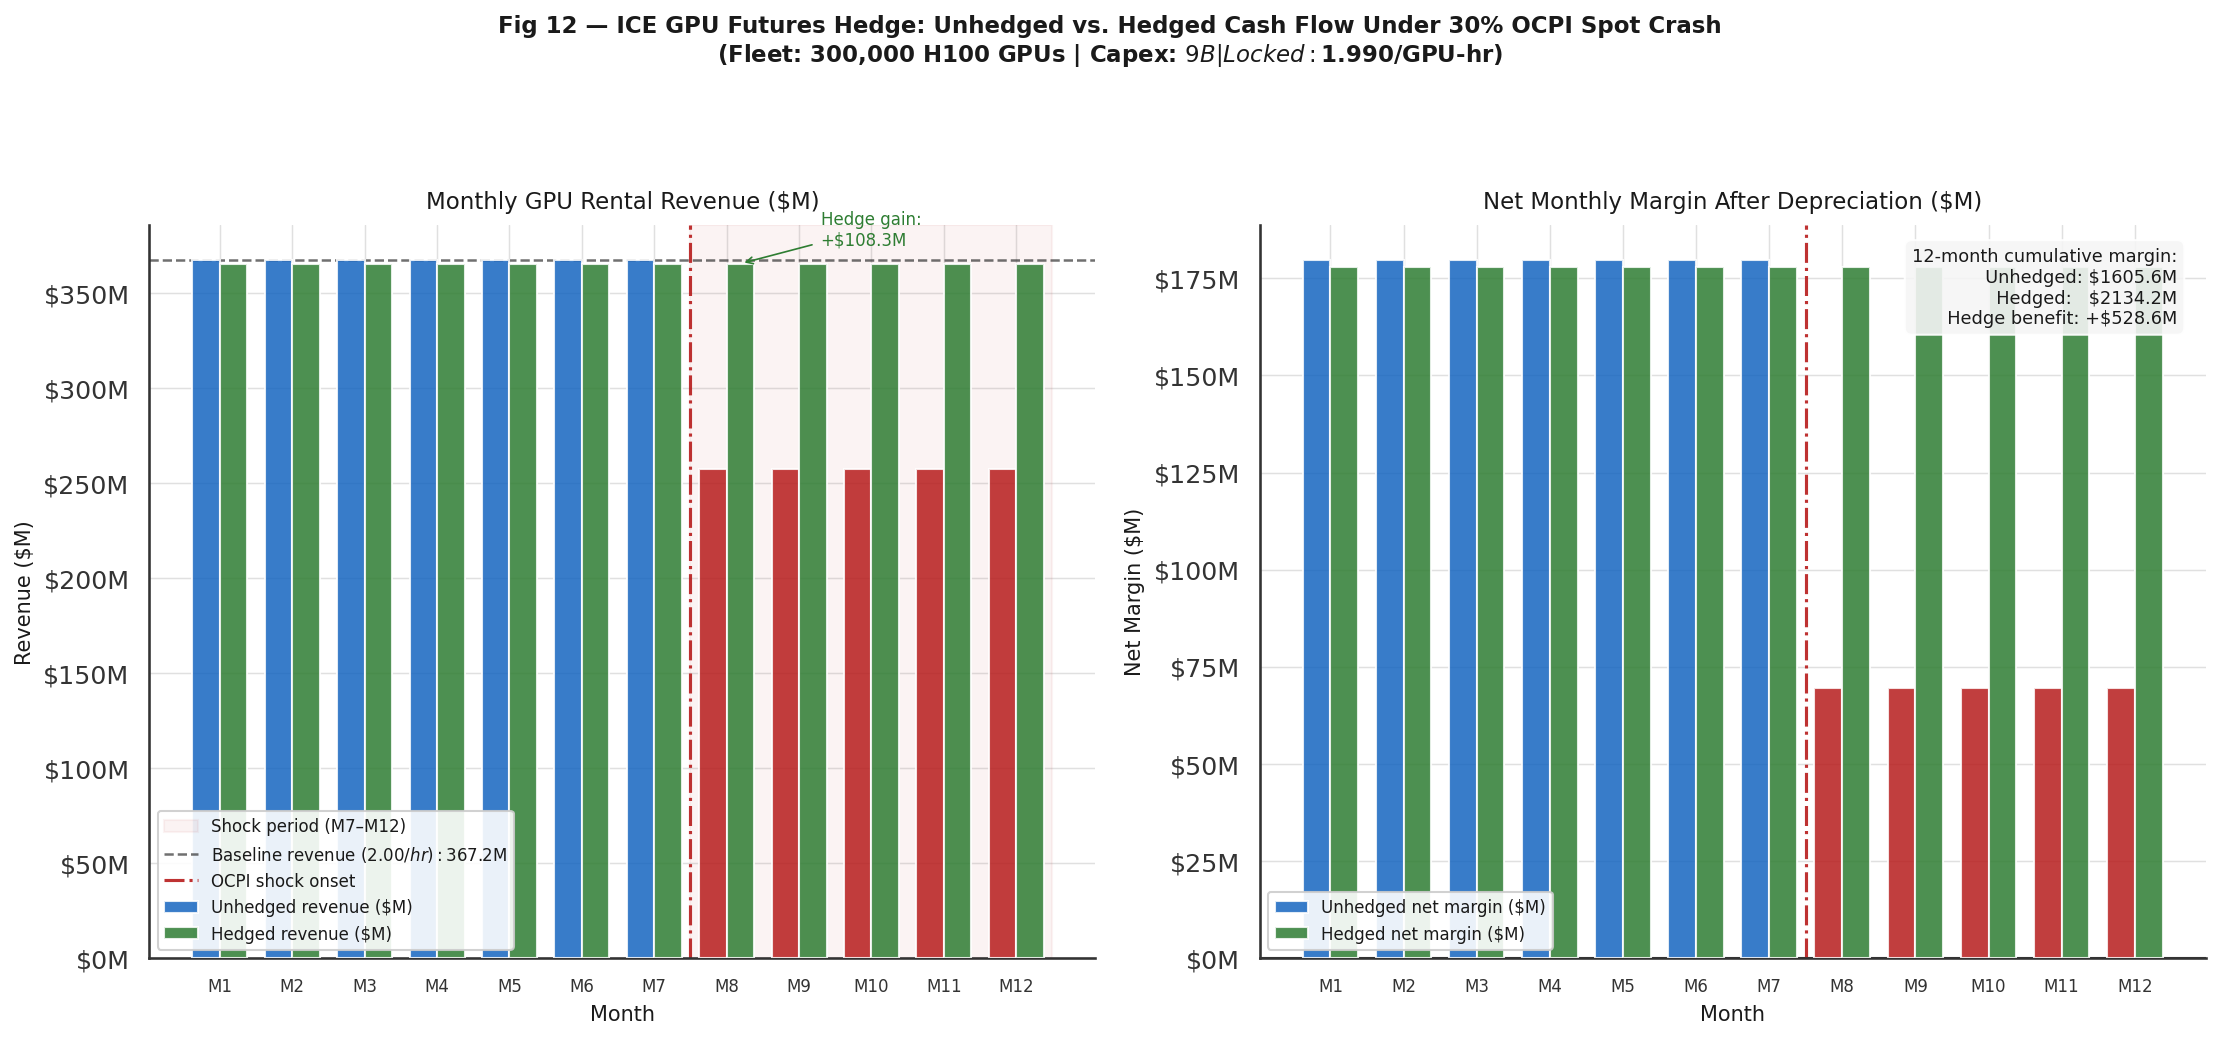

In [5]:
# Figure 12: Hedged vs Unhedged Cash Flow Outcomes Under 30% Spot Crash
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle(
    "Fig 12 — ICE GPU Futures Hedge: Unhedged vs. Hedged Cash Flow Under 30% OCPI Spot Crash\n"
    f"(Fleet: {N_GPUS:,} H100 GPUs | Capex: ${CAPEX_TOTAL_B:.0f}B | Locked: ${LOCKED_RATE:.3f}/GPU-hr)",
    fontsize=11, fontweight="bold", y=0.99
)

month_labels = [f"M{m+1}" for m in months_idx]
bar_w        = 0.38
x            = np.arange(HORIZON_MONTHS)

# ── Left: Monthly Revenue (unhedged vs hedged) ───────────────────────────────
ax = axes[0]
bars_u = ax.bar(x - bar_w/2, unhedged_rev_B * 1e3, bar_w,
                color=[SCENARIO_COLORS["systemic"] if m >= STRESS_MONTH
                       else "#1565C0" for m in months_idx],
                alpha=0.85, label="Unhedged revenue ($M)", zorder=3)
bars_h = ax.bar(x + bar_w/2, hedged_rev_B * 1e3, bar_w,
                color=SCENARIO_COLORS["fizzle"], alpha=0.85,
                label="Hedged revenue ($M)", zorder=3)

# Shade shock region
ax.axvspan(STRESS_MONTH - 0.5, HORIZON_MONTHS - 0.5,
           color=SCENARIO_COLORS["systemic"], alpha=0.05,
           label="Shock period (M7–M12)")
ax.axhline(OCPI_SPOT * monthly_gpu_hours / 1e9 * 1e3,
           color="#333333", linewidth=1.2, linestyle="--", alpha=0.7,
           label=f"Baseline revenue (${OCPI_SPOT:.2f}/hr): ${OCPI_SPOT*monthly_gpu_hours/1e9*1e3:.1f}M")
ax.axvline(STRESS_MONTH - 0.5, color=SCENARIO_COLORS["systemic"],
           linewidth=1.5, linestyle="-.", alpha=0.9, label="OCPI shock onset")

# Annotate the gap at first post-shock month
m_shock = STRESS_MONTH
gap = (hedged_rev_B[m_shock] - unhedged_rev_B[m_shock]) * 1e3
ax.annotate(f"Hedge gain:\n+${gap:.1f}M",
            xy=(m_shock + bar_w/2, hedged_rev_B[m_shock] * 1e3),
            xytext=(m_shock + 1.3, hedged_rev_B[m_shock] * 1e3 + 10),
            fontsize=8, color=SCENARIO_COLORS["fizzle"],
            arrowprops=dict(arrowstyle="->", color=SCENARIO_COLORS["fizzle"], lw=0.8))

ax.set_title("Monthly GPU Rental Revenue ($M)", fontsize=11, pad=8)
ax.set_xlabel("Month", fontsize=10)
ax.set_ylabel("Revenue ($M)", fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(month_labels, fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:.0f}M"))
ax.legend(fontsize=8, loc="lower left")
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)

# ── Right: Net Margin (Revenue - Depreciation) ────────────────────────────────
ax2 = axes[1]
ax2.bar(x - bar_w/2, unhedged_margin_B * 1e3, bar_w,
        color=[SCENARIO_COLORS["systemic"] if m >= STRESS_MONTH
               else "#1565C0" for m in months_idx],
        alpha=0.85, label="Unhedged net margin ($M)", zorder=3)
ax2.bar(x + bar_w/2, hedged_margin_B * 1e3, bar_w,
        color=SCENARIO_COLORS["fizzle"], alpha=0.85,
        label="Hedged net margin ($M)", zorder=3)

ax2.axhline(0, color="#333333", linewidth=1.0)
ax2.axvline(STRESS_MONTH - 0.5, color=SCENARIO_COLORS["systemic"],
            linewidth=1.5, linestyle="-.", alpha=0.9)
ax2.axhspan(0, 0, color="white")   # zero reference

# Summary annotation
cum_unhedged_B = unhedged_margin_B.sum()
cum_hedged_B   = hedged_margin_B.sum()
ax2.text(0.97, 0.97,
         f"12-month cumulative margin:\n"
         f"  Unhedged: ${cum_unhedged_B*1e3:.1f}M\n"
         f"  Hedged:   ${cum_hedged_B*1e3:.1f}M\n"
         f"  Hedge benefit: +${(cum_hedged_B - cum_unhedged_B)*1e3:.1f}M",
         transform=ax2.transAxes, fontsize=8.5, va="top", ha="right",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#f5f5f5", alpha=0.9))

ax2.set_title("Net Monthly Margin After Depreciation ($M)", fontsize=11, pad=8)
ax2.set_xlabel("Month", fontsize=10)
ax2.set_ylabel("Net Margin ($M)", fontsize=10)
ax2.set_xticks(x); ax2.set_xticklabels(month_labels, fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:.0f}M"))
ax2.legend(fontsize=8, loc="lower left")
for sp in ["top", "right"]:
    ax2.spines[sp].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.93])
out12 = FIGURES_DIR / "fig12_gpu_hedge_pnl.png"
plt.savefig(out12, dpi=300, bbox_inches="tight", facecolor="white")
print(f"Saved: {out12}")
plt.show()


## Validation Assertions

In [6]:
# Final validation assertions
print("Running Module 3 compute derivatives assertions...")

# 1. OCPI forward curve: F(0) equals spot
assert abs(forward_prices[0] - OCPI_SPOT) < 1e-6, \
    f"Spot price mismatch: F(0)={forward_prices[0]:.6f} vs OCPI_SPOT={OCPI_SPOT}"
print(f"  PASS  OCPI F(0) = ${forward_prices[0]:.4f}/GPU-hr (matches spot)")

# 2. Peak contango is positive and within months 3-9
assert forward_prices.max() > OCPI_SPOT, "Forward curve must have contango above spot"
assert 3 <= peak_month <= 9, f"Peak contango month {peak_month} out of expected range 3-9"
print(f"  PASS  Peak contango = +{(forward_prices[peak_month]/OCPI_SPOT-1)*100:.1f}% at month {peak_month}")

# 3. Long-term backwardation: 24-month forward below spot
assert forward_prices[-1] < OCPI_SPOT, "24-month forward must be below spot (backwardation)"
print(f"  PASS  M24 backwardation = {(forward_prices[-1]/OCPI_SPOT-1)*100:.1f}%")

# 4. Hedge effectiveness > 95%
assert hedge_efficiency >= 0.95, \
    f"Hedge effectiveness {hedge_efficiency*100:.1f}% below 95% threshold"
print(f"  PASS  Hedge effectiveness = {hedge_efficiency*100:.1f}%")

# 5. Stressed revenue < baseline revenue
baseline_monthly = OCPI_SPOT * monthly_gpu_hours / 1e9
stressed_monthly = OCPI_SPOT * (1 - STRESS_CRASH) * monthly_gpu_hours / 1e9
assert stressed_monthly < baseline_monthly, "Stressed revenue must be below baseline"
print(f"  PASS  Stressed revenue ${stressed_monthly*1e3:.1f}M < Baseline ${baseline_monthly*1e3:.1f}M/month")

# 6. Hedged revenue approximately equals locked rate (within 2% of baseline)
hedged_monthly = LOCKED_RATE * monthly_gpu_hours / 1e9
tolerance      = 0.02
drift_pct      = abs(hedged_monthly - baseline_monthly) / baseline_monthly
assert drift_pct < tolerance, \
    f"Hedge drift {drift_pct*100:.2f}% exceeds {tolerance*100:.0f}% tolerance"
print(f"  PASS  Hedged ${hedged_monthly*1e3:.1f}M vs Baseline ${baseline_monthly*1e3:.1f}M "
      f"(drift {drift_pct*100:.2f}%)")

# 7. Figures saved with sufficient size
for fname in ["fig11_ocpi_forward_curve.png", "fig12_gpu_hedge_pnl.png"]:
    fpath = FIGURES_DIR / fname
    assert fpath.exists() and fpath.stat().st_size > 30_000, \
        f"{fname} missing or too small ({fpath.stat().st_size if fpath.exists() else 0} bytes)"
    print(f"  PASS  {fname}  ({fpath.stat().st_size // 1024}KB)")

print("\nAll Module 3 assertions passed.")
print(f"\n{'='*60}")
print("HEDGED PnL OFFSET SUMMARY")
print(f"{'='*60}")
print(f"  30% OCPI spot crash at month {STRESS_MONTH}:")
print(f"    Revenue shortfall (M{STRESS_MONTH}-M{HORIZON_MONTHS-1}, unhedged) : ${stress_impact_unhedged_B*1e3:.1f}M")
print(f"    Futures gain (ICE GPU short, M{STRESS_MONTH}-M{HORIZON_MONTHS-1})  : +${cumulative_hedge_gain_B*1e3:.1f}M")
print(f"    Net residual P&L                          : ${(stress_impact_unhedged_B + cumulative_hedge_gain_B)*1e3:.1f}M")
print(f"    Hedge effectiveness                       : {hedge_efficiency*100:.1f}%")
print(f"  12-month margin advantage (hedged - unhedged): +${(cum_hedged_B - cum_unhedged_B)*1e3:.1f}M")


Running Module 3 compute derivatives assertions...
  PASS  OCPI F(0) = $2.0000/GPU-hr (matches spot)
  PASS  Peak contango = +1.7% at month 5
  PASS  M24 backwardation = -46.4%
  PASS  Hedge effectiveness = 98.3%
  PASS  Stressed revenue $257.0M < Baseline $367.2M/month
  PASS  Hedged $365.4M vs Baseline $367.2M (drift 0.50%)
  PASS  fig11_ocpi_forward_curve.png  (334KB)
  PASS  fig12_gpu_hedge_pnl.png  (320KB)

All Module 3 assertions passed.

HEDGED PnL OFFSET SUMMARY
  30% OCPI spot crash at month 7:
    Revenue shortfall (M7-M11, unhedged) : $-550.8M
    Futures gain (ICE GPU short, M7-M11)  : +$541.6M
    Net residual P&L                          : $-9.2M
    Hedge effectiveness                       : 98.3%
  12-month margin advantage (hedged - unhedged): +$528.6M
